In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import userdata
import os

token = userdata.get('GITHUB_TOKEN')


username = "avatarmongacancode34"
repo = "lab-3"
remote_url = f"https://{token}@github.com/{username}/{repo}.git"
os.system(f"git remote set-url origin {remote_url}")

32768

In [3]:
!git config --global user.email "shaun.sibanda@ashesi.edu.gh"
!git config --global user.name "Sibanda Shaun M"

In [4]:
%cd /content/drive/MyDrive/MyGitProjects/lab-3

/content/drive/MyDrive/MyGitProjects/lab-3


# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Shaun M Sibanda
**Student ID:** 60932028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [5]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

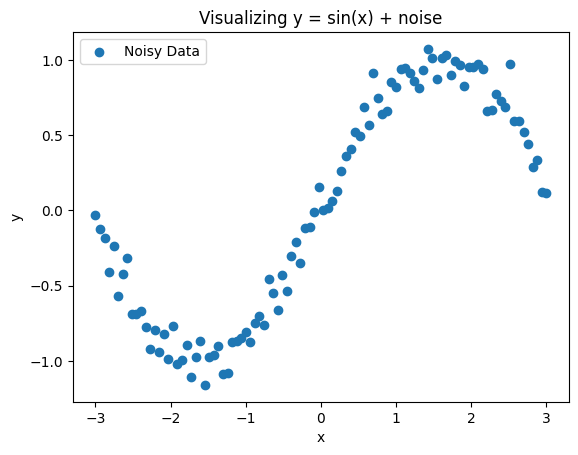

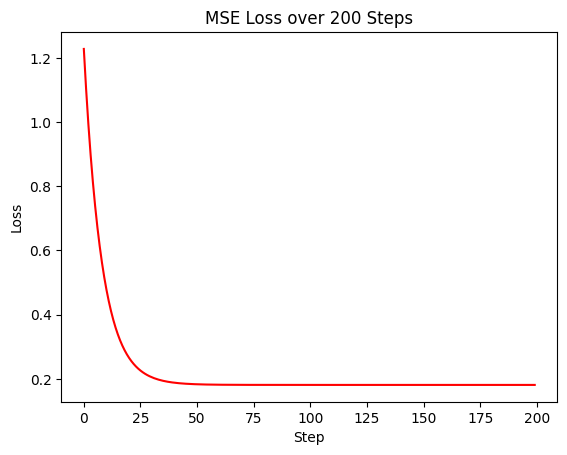

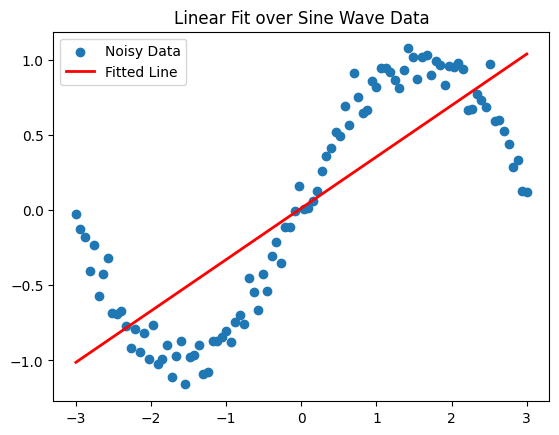

In [8]:
# TODO: Generating toy data
x = np.linspace(-3, 3, 100)
Clean_y = np.sin(x)
noise =  np.random.normal(loc=0.0, scale=0.1, size=x.shape)
y = Clean_y + noise

# first plot
plt.figure()
plt.scatter(x, y, label="Noisy Data")
plt.title("Visualizing y = sin(x) + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Initialising variables
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5
lr = 0.01
loss_values = []

# gradient-descent for 200 steps:
for _ in range(200):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)               # MSE- of the output
  # back propagation
  dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
  db    = np.mean(2 * (y_hat - y))                # dLoss/db

  # new weight and bias
  w    -= lr * dw
  b    -= lr * db
  loss_values.append(loss)


#2nd plot

plt.figure()
plt.plot(loss_values, color="red")
plt.title("MSE Loss over 200 Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()



# final prediction
final_y_hat = w * x + b

# 3rd plot
plt.figure()
plt.scatter(x, y, label="Noisy Data")
plt.plot(x, final_y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Linear Fit over Sine Wave Data")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
2. The fit is underfitting because the model is too weak for the complexity of the data. The single neuron here behaves like a straight line and so it can never bend to fit a sine wave even if it is trained for a long time.

1. The derived formulas match the code and here is the image of it
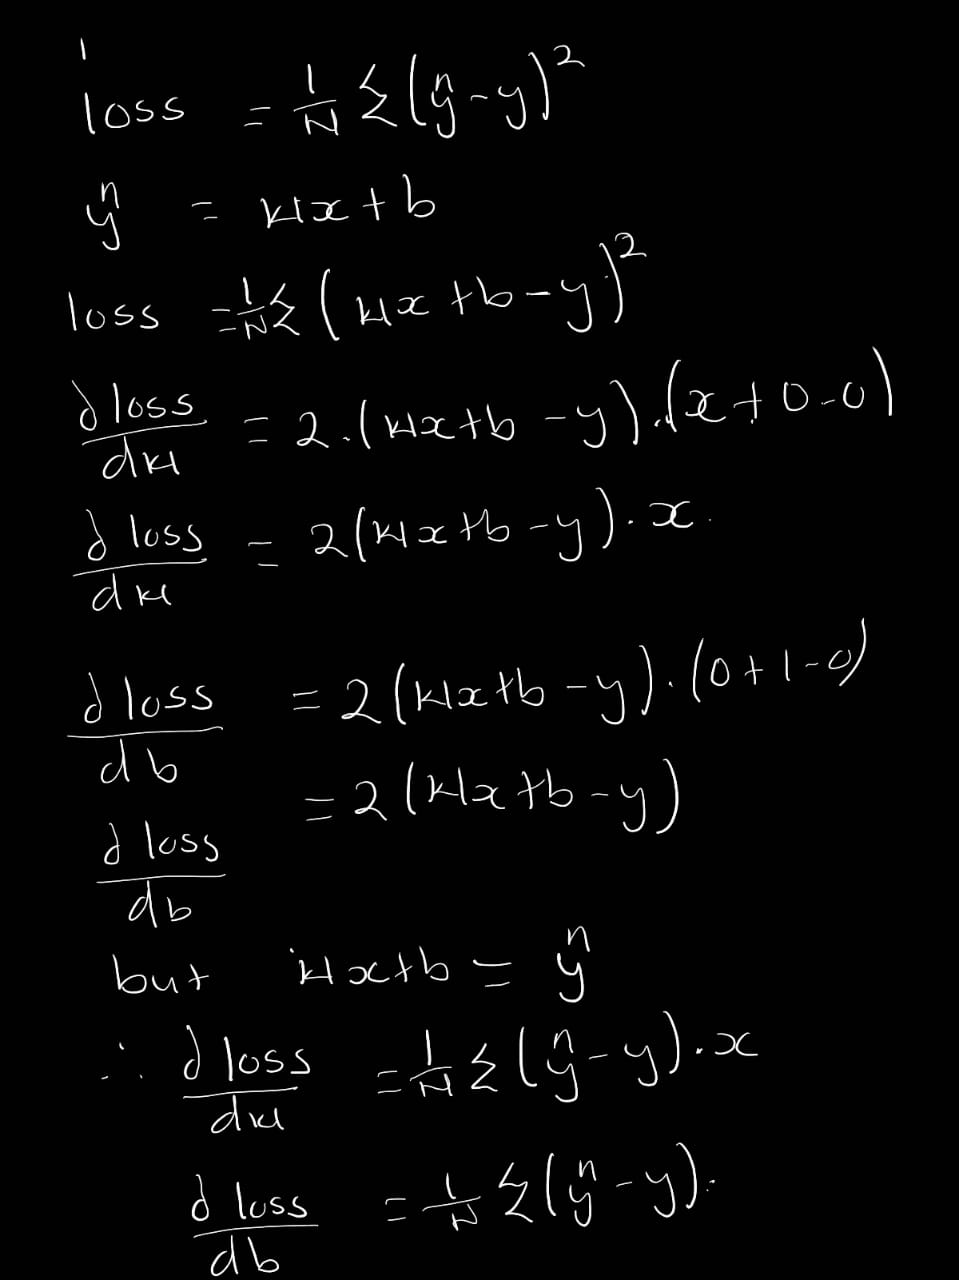

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

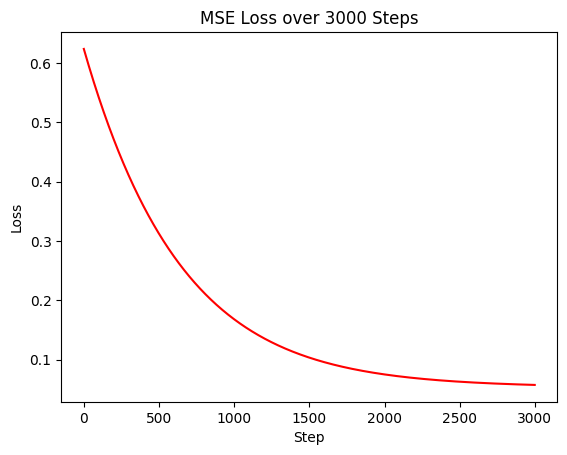

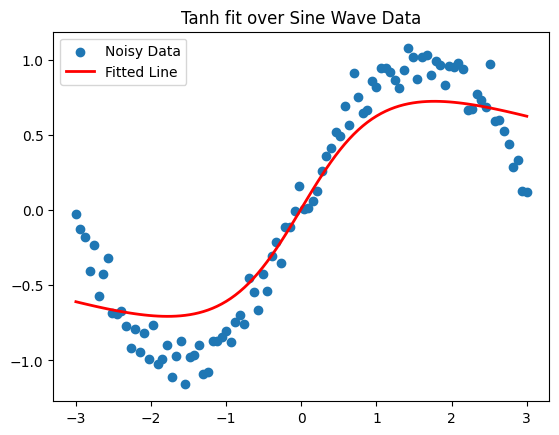

In [11]:
# Initialise parameters

W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros((1,))
lr = 0.0001
loss_values = []
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Forward pass
for i in range(3000):
  z1 = x @ W1 + b1        # pre-activation
  h  = np.tanh(z1)        # activation
  y_hat = h @ W2 + b2     # output
  loss  = np.mean((y_hat - y) ** 2)

# Backward pass
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2
  loss_values.append(loss)

# the loss curve AND
plt.figure()
plt.plot(loss_values, color="red")
plt.title("MSE Loss over 3000 Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

# the final fit over the data.

z1 = x @ W1 + b1
h  = np.tanh(z1)
final_y_hat = h @ W2 + b2

plt.figure()
plt.scatter(x, y, label="Noisy Data")
plt.plot(x, final_y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Tanh fit over Sine Wave Data")
plt.legend()
plt.show()




Test plot to sea what each of the four neurons do

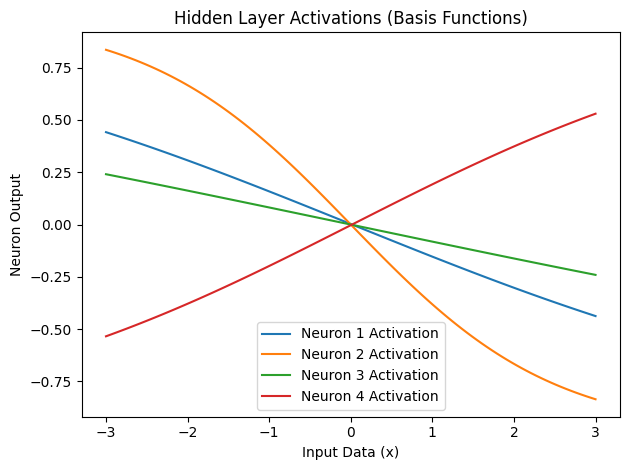

In [9]:
for i in range(4):

    plt.plot(x, h[:, i], label=f'Neuron {i+1} Activation')

plt.title("Hidden Layer Activations (Basis Functions)")
plt.xlabel("Input Data (x)")
plt.ylabel("Neuron Output")
plt.legend()
plt.tight_layout()
plt.show()

Making all the neurons linear

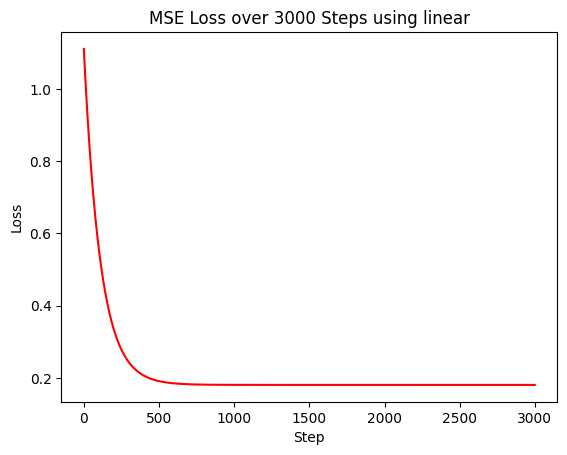

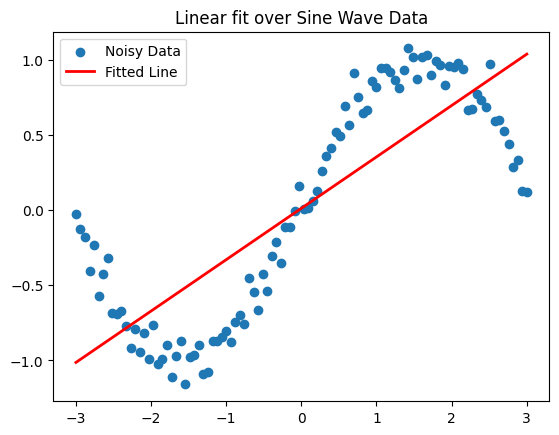

In [12]:
# h = z1)

# initializng variables
W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros((1,))
lr = 0.0001
loss_values = []

for _ in range(3000):
  z1 = x @ W1 + b1
  h  = z1
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y) ** 2)

# Backward pass
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * 1    # derivative of z1
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2
  loss_values.append(loss)

# plot 1

plt.figure()
plt.plot(loss_values, color="red")
plt.title("MSE Loss over 3000 Steps using linear")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

# plot 2

z1 = x @ W1 + b1
h  = z1
final_y_hat = h @ W2 + b2

plt.figure()
plt.scatter(x, y, label="Noisy Data")
plt.plot(x, final_y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Linear fit over Sine Wave Data")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. The reason why the deep network behaves like a linear layer is because of the associative and distributive nature of matrices. As demonstrated by the image below, the equations will still sum up to produce an overall linear equation which makes it behave just like a linear neuron.
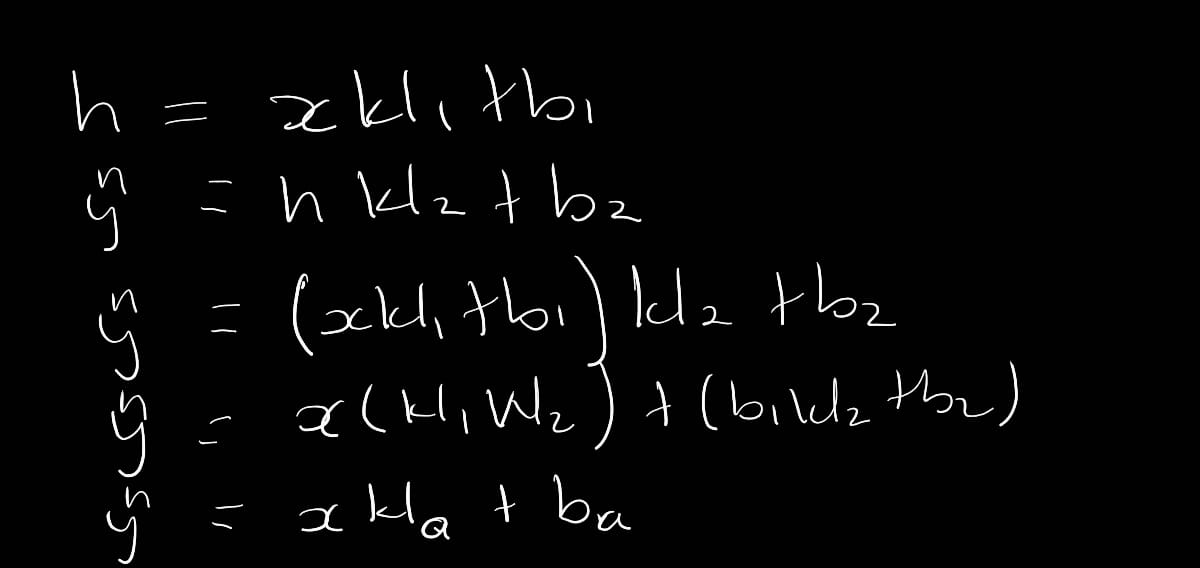
2. When tanh is used, each of the 8 neurons takes an input and creates a small curve of it based on it's weight and biases. These curves are summed upto produce a final non linear output.This demonstrated in the test plot I did for 4 activations.
3. With this observation back propagation is the process of using the chain rule to calculate the gradient of a loss function and then using it to correct the weights and biases in a neural network

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_7157/2369159939.py:12: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_7157/2369159939.py:18: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_7157/2369159939.py:19: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


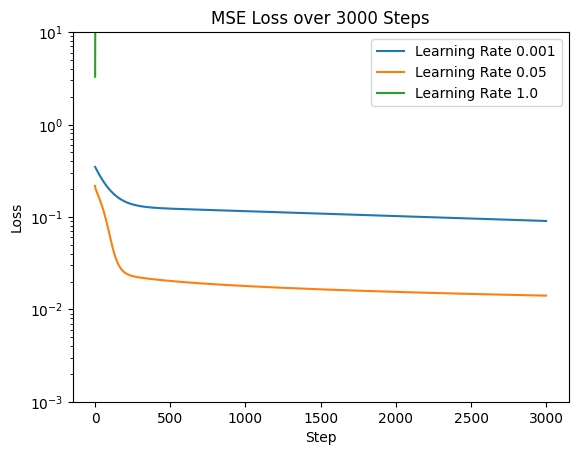

In [21]:
def train_toy(lr, steps=3000):
  torch.manual_seed(RANDOM_STATE)
  loss_values = []
  W1 = np.random.randn(1,8) * 0.5
  b1 = np.zeros((8,))
  W2 = np.random.randn(8,1) * 0.5
  b2 = np.zeros((1,))
  for _ in range(steps):
    z1 = x @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)


    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    loss_values.append(loss)
  return loss_values

# comparing learning rates
losses = []
learning_rates = [0.001, 0.05, 1.0]
for lr in learning_rates:
  losses.append(train_toy(lr))
plt.figure()
for i, loss in enumerate(losses):
  plt.plot(loss, label=f'Learning Rate {learning_rates[i]}')
plt.title("MSE Loss over 3000 Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.yscale("log")
plt.ylim(bottom=1e-3, top=10)
plt.legend()
plt.show()




**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** When the learning rate is too large the steps become too large such that you pass the lowest gradient and you end up at the opposite high end. If the learning rate is too small, it will take too many steps to find the right gradient. The learning rate should should balance the two so that each steps gets you closer to the gradient.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [13]:
#dataset
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# Encode categoricals
binary_map = {'yes': 1, 'no': 0}

binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].str.lower().map(binary_map)

from sklearn.preprocessing import LabelEncoder

ordinal_mapping = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
for col in ['CAEC', 'CALC']:
    obesity[col] = obesity[col].map(ordinal_mapping)

obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True,dtype=int)


le = LabelEncoder()
obesity['NObeyesdad'] = le.fit_transform(obesity['NObeyesdad'])



# Stratified train / validation / test split (60/20/20, stratify=y,

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X = obesity.drop('NObeyesdad', axis=1)
y = obesity['NObeyesdad']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


import torch
from torch.utils.data import TensorDataset, DataLoader


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**
1. CrossEnropyLoss uses integer labels because they take less space and they are easier to compute compared to one hot which would create a column for every class in y.
2. The dw formular multiplies x to find the gradient. So in a case where x are of different measurements, the gradients calculated will be significantly different. The network will be stuck oscillating in the axis with bigger gradients.
3. Shuffle = True to randomize the order data that the network receives, if it receives class 0 first, then class 1, by the time it gets to class 3 it would have forgotten the weights of class one and optimizing the weights only to get good at class 3.


### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [14]:

import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()


        layers = []


        current_dim = input_dim


        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(current_dim, hidden_size))
            layers.append(nn.ReLU())
            current_dim = hidden_size


        layers.append(nn.Linear(current_dim, n_classes))


        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)



model = FeedForwardNet(input_dim=X_train_tensor.shape[1], hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(X_train_tensor.shape[1])
print(trainable_params)

count = X_train_tensor.shape[1]* 64 + 64
print(count)


19
3591
1280


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
1. By calculation, there are 19 inputs * 64 weights + 64 biases for the first layer = 1280, then 64 inputs * 32 weights + 32 biases in the second layer = 2080 and finaly 32 inputs * 7 weights + 7 biases in the outer layer = 231. In total the sum of parameters is 3591, which is equivalent to the output from PyTorch.
2. Tanh has a problem trying squash all inputs into range of -1 and 1. So when the get too big, the curve flattens cause the gradient to be almost zero which causes the vanishing gradient effect. On the other hand, ReLu creates a straight line with constant gradient of one and so there is no possibility of vanishing gradient.
3. Just like in the experiment if the ReLu activations are removed the network will behave like a linear network and fail to predict the non linear outputs.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 0.0170 - Train Acc: 1.0000 | Val Loss: 0.5870 - Val Acc: 0.9052
Epoch 02/50 | Train Loss: 0.0143 - Train Acc: 1.0000 | Val Loss: 0.5996 - Val Acc: 0.8934
Epoch 03/50 | Train Loss: 0.0146 - Train Acc: 1.0000 | Val Loss: 0.6215 - Val Acc: 0.9076
Epoch 04/50 | Train Loss: 0.0141 - Train Acc: 1.0000 | Val Loss: 0.6396 - Val Acc: 0.8957
Epoch 05/50 | Train Loss: 0.0122 - Train Acc: 1.0000 | Val Loss: 0.6356 - Val Acc: 0.9052
Epoch 06/50 | Train Loss: 0.0103 - Train Acc: 1.0000 | Val Loss: 0.6452 - Val Acc: 0.9052
Epoch 07/50 | Train Loss: 0.0100 - Train Acc: 1.0000 | Val Loss: 0.6415 - Val Acc: 0.9028
Epoch 08/50 | Train Loss: 0.0088 - Train Acc: 1.0000 | Val Loss: 0.6531 - Val Acc: 0.9005
Epoch 09/50 | Train Loss: 0.0092 - Train Acc: 1.0000 | Val Loss: 0.6614 - Val Acc: 0.9005
Epoch 10/50 | Train Loss: 0.0077 - Train Acc: 1.0000 | Val Loss: 0.6676 - Val Acc: 0.9028
Epoch 11/50 | Train Loss: 0.0071 - Train Acc: 1.0000 | Val Loss: 0.6656 - Val Acc: 0.8981
Epoch 12/5

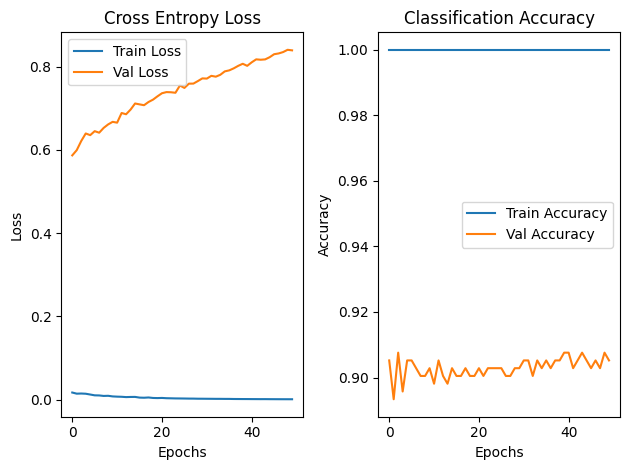

In [ ]:
model.to(DEVICE)

# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# I chose Adam because it calculates a separate learning rate for each parameter, and that makes it converge faster and save time

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

best_val_acc = 0.0
num_epochs = 50
def evaluate(loader):
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, correct / total

for epoch in range(1, num_epochs + 1):
  model.train()
  for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        # foward pass
        logits = model(xb)
        loss = criterion(logits, yb)
        # coumputing gradient
        loss.backward()
        # The update rule
        optimizer.step()
  model.eval()

  with torch.no_grad():
    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")


plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Cross Entropy Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**
1. forward pass line `logits=model(xb)`, computing gradient line is `loss.backward()`, and the update rule line is `optimizer.step()`

2. Looking at the outputs, the model is predicts 100% of training data, but 90% of validation data. Additionaly, the loss from training data gradually gets to zero while the loss of validation data keeps worsening. This shows that the model memorized the training data, but fails when given validation data. Therefore its overfitting.

3. Pytorch does not replace the gradients with the new calculated gradient, it adds them instead. So this will end up giving non optimal weights and biases. Hence it is necessary to set the gradient to zero for every iteration so that the calculated gradient is not affected by the previous gradient.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

Running exp: hidden=(8,), lr=0.001, batch=32, drop=0.0
Running exp: hidden=(64, 32), lr=0.001, batch=32, drop=0.0
Running exp: hidden=(256, 128, 64), lr=0.001, batch=32, drop=0.0
Running exp: hidden=(64, 32), lr=0.0001, batch=32, drop=0.0
Running exp: hidden=(64, 32), lr=0.001, batch=32, drop=0.0
Running exp: hidden=(64, 32), lr=0.1, batch=32, drop=0.0
Running exp: hidden=(256, 128, 64), lr=0.001, batch=32, drop=0.0
Running exp: hidden=(256, 128, 64), lr=0.001, batch=32, drop=0.3


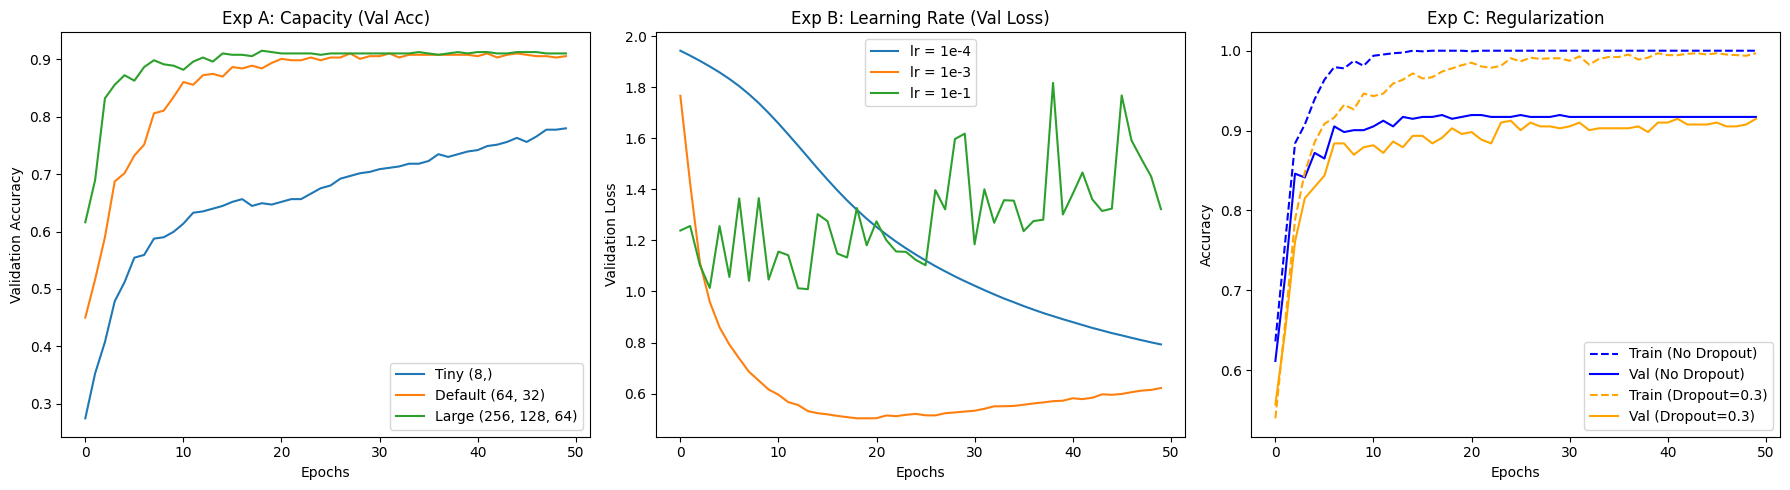

In [ ]:
def evaluate(loader, eval_model, eval_criterion):
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = eval_model(xb)
            loss = eval_criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super(FeedForwardNet, self).__init__()
        layers = []
        current_dim = input_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(current_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            current_dim = hidden_size

        layers.append(nn.Linear(current_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    print(f"Running exp: hidden={hidden_sizes}, lr={lr}, batch={batch_size}, drop={dropout}")

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Instantiation
    model = FeedForwardNet(
        input_dim=X_train_tensor.shape[1],
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # Training Loop
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        train_loss, train_acc = evaluate(train_loader, model, criterion)
        val_loss, val_acc = evaluate(val_loader, model, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

# Experiment A: Capacity (Hidden Sizes)

hist_tiny = run_experiment(hidden_sizes=(8,))
hist_def = run_experiment(hidden_sizes=(64, 32))
hist_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_tiny['val_acc'], label='Tiny (8,)')
plt.plot(hist_def['val_acc'], label='Default (64, 32)')
plt.plot(hist_large['val_acc'], label='Large (256, 128, 64)')
plt.title('Exp A: Capacity (Val Acc)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()


# Experiment B: Learning Rate

hist_lr_small = run_experiment(lr=1e-4)
hist_lr_def = run_experiment(lr=1e-3)
hist_lr_large = run_experiment(lr=1e-1)

plt.subplot(1, 3, 2)
plt.plot(hist_lr_small['val_loss'], label='lr = 1e-4')
plt.plot(hist_lr_def['val_loss'], label='lr = 1e-3')
plt.plot(hist_lr_large['val_loss'], label='lr = 1e-1')
plt.title('Exp B: Learning Rate (Val Loss)')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()


# Experiment C:

hist_no_drop = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
hist_drop = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

plt.subplot(1, 3, 3)
# without Dropout
plt.plot(hist_no_drop['train_acc'], label='Train (No Dropout)', linestyle='--', color='blue')
plt.plot(hist_no_drop['val_acc'], label='Val (No Dropout)', color='blue')
# Dropout lines
plt.plot(hist_drop['train_acc'], label='Train (Dropout=0.3)', linestyle='--', color='orange')
plt.plot(hist_drop['val_acc'], label='Val (Dropout=0.3)', color='orange')
plt.title('Exp C: Regularization')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**
1. The largest capacity did not necessarily win, although it got to it's peak accuracy earlier than default, it's max accuracy was the same as the default. The diminishing began at the peak of the default capacity which shows that increasing capacity beyond the default did not provide any meaningful extra generalization.

2. The three graphs show what I saw in part 1.3 because the largest learning rate had oscilations as it kept on missing the optimal gradient, while the smaller learning rate failed to converge within the 50 epochs while the learning rate of 1e-3 found the minimum easily.

3. Drop out tried to reduce the gap between train and validation. Before droupout, the train data had an accuracy of 1.0 but it lowered when dropout was introduced. This is because randomly disabled 30% of some neurons in every stap. This forced the model to actually learn instead of neuron memorizing data.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9243
Test Macro-F1: 0.9222

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.94      0.95        54
      Normal_Weight       0.80      0.78      0.79        58
     Obesity_Type_I       0.99      0.94      0.96        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.80      0.84      0.82        58
Overweight_Level_II       0.92      0.98      0.95        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.93      0.92      0.92       423



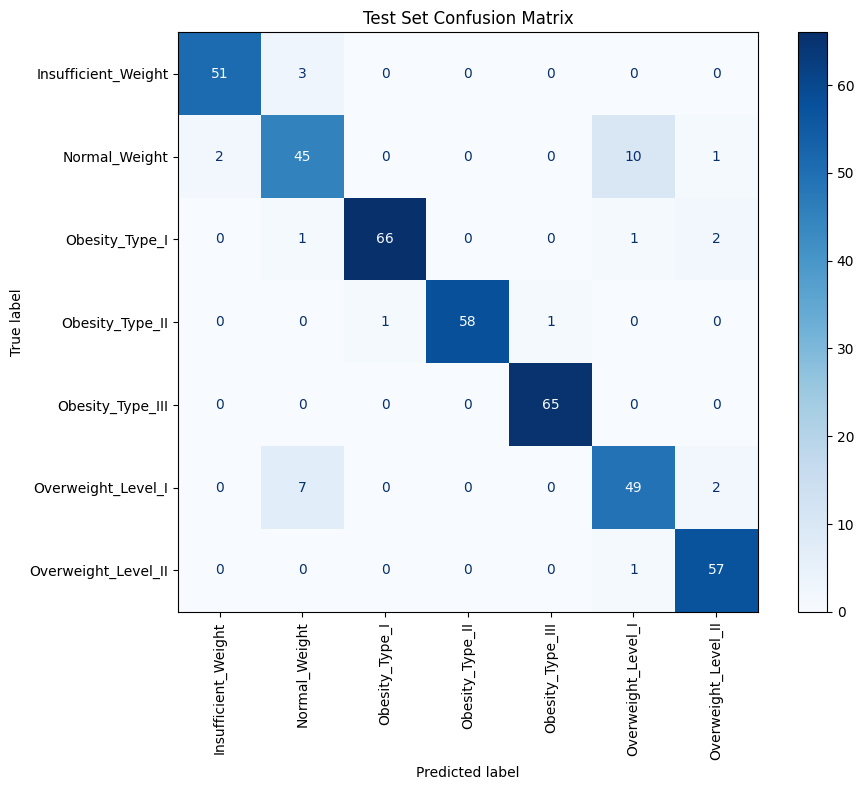

,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters/Trees
0,"Lab 2 Classifier (e.g., Random Forest)",0.92670,0.926200,2s,100 Trees
1,PyTorch FFN,0.92435,0.922171,1s,3591


In [19]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
# TODO: Load your best configuration's weights; model.eval().
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()



test_preds = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)


        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(yb.numpy())
test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}\n")
print("Classification Report:")

print(classification_report(test_targets, test_preds, target_names=le.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_preds,
    display_labels=le.classes_,
    xticks_rotation='vertical',
    cmap='Blues',
    ax=ax
)
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison_data = {
    "Model": ["Lab 2 Classifier (e.g., Random Forest)", "PyTorch FFN"],
    "Test Accuracy": [0.9267, test_acc],
    "Test Macro-F1": [0.9262, test_f1],
    "Training Time": ["2s", "1s"],
    "Parameters/Trees": ["100 Trees", trainable_params]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:**
1. The network still confuses overwheight level 1 with normal weight. This is the same mistake that the classifier made in lab 2

2. Although Pytorch ran faster than RandomForest by accuracy RandomForest had better accuracy. Additionaly RandomForst was easier to implement compared to Pytorch. Due to this deeplearning was not worth it in this dataset. It would have been worth it in large unstructured data like image processing where RandomForest would fail

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.

In [ ]:
!git add .
!git commit -m "added evaluations in 2.5"

os.system("git push -u origin main")

[main e34cf3d] added evaluations in 2.5
 1 file changed, 1 insertion(+), 1 deletion(-)


0